# Breast Cancer Diagnosis Prediction 
###  Project Goal
The primary goal of this project is to build, train, and evaluate a robust machine learning classification model capable of accurately distinguishing between Malignant and Benign tumors based on nuclear features of cells collected via Fine Needle Aspiration (FNA).

### Dataset Overview
- Source: sklearn.datasets.load_breast_cancer (based on the original Wisconsin Breast Cancer Diagnostic dataset).

- Target Variable: diagnosis (encoded as target in the DataFrame).

- Class 0: Malignant (212 samples)

- Class 1: Benign (357 samples)

- Features (30): Continuous numerical measurements describing characteristics like radius, texture, perimeter, area, and concave points for the cell nuclei.

## Part 1 - Environment Setup

### Import the necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report 
import joblib 

In [2]:
import warnings
warnings.filterwarnings(action='ignore')

### Load the dataset (local)

In [3]:
df = pd.read_csv('dataset/breast-cancer.csv')
display(df.head())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Part 2 - Load and Inspect Data

### Load the breast_cancer dataset from sklearn

In [4]:
from sklearn.datasets import load_breast_cancer

In [5]:
cancer = load_breast_cancer()
print('Dataset loaded from sklearn.datasets.load_breast_cancer')

Dataset loaded from sklearn.datasets.load_breast_cancer


### Convert the data to a pandas DataFrame for easier viewing and analysis


In [6]:
# X (features) are in 'data' and y (target) are in 'target'
df_features = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df_target = pd.DataFrame(cancer.target, columns=['target'])

# Concatenate features and target into a single DataFrame
df_cancer = pd.concat([df_features, df_target], axis=1)

### Print the first five rows of the dataset

In [7]:
print('First 5 rows of the DataFrame')
display(df_cancer.head())

First 5 rows of the DataFrame


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### target column values

In [8]:
print(f'Unique target values (Raw): {df_cancer['target'].unique()}')

Unique target values (Raw): [0 1]


In [9]:
print('Target Class Names (Meaning):')
for i, name in enumerate(cancer.target_names):
    print(f'Value {i}: *{name}*')

Target Class Names (Meaning):
Value 0: *malignant*
Value 1: *benign*


### Check the number of rows and columns (Shape)


In [10]:
print('Distribution of Target Classes:')
print(df_cancer['target'].value_counts())

Distribution of Target Classes:
target
1    357
0    212
Name: count, dtype: int64


In [11]:
print('Dataset Shape ')
# (Rows, Columns)
print(f'The dataset has {df_cancer.shape[0]} rows and {df_cancer.shape[1]} columns.')

Dataset Shape 
The dataset has 569 rows and 31 columns.


## Part 3. Data Analysis

### Calculate the distribution of classes (Malignant vs. Benign)


In [12]:
print('Class Distribution (Target)')
class_mapping = {0: 'Malignant', 1: 'Benign'}

Class Distribution (Target)


In [13]:
print('Distribution of Target Classes:')
class_counts = df_cancer['target'].value_counts()
mapped_counts = class_counts.rename(index=class_mapping)

# Print the results
print(mapped_counts)
print(f'Total Samples: {df_cancer.shape[0]}')

Distribution of Target Classes:
target
Benign       357
Malignant    212
Name: count, dtype: int64
Total Samples: 569


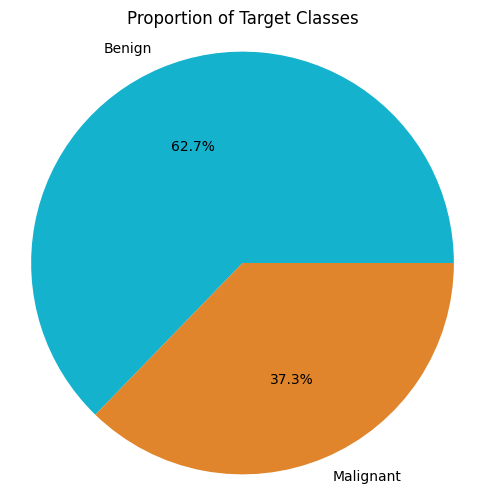

In [14]:
labels = [class_mapping[i] for i in class_counts.index]

plt.figure(figsize=(6, 6))
# Plot the pie chart
plt.pie(
    class_counts, 
    labels= labels,
    autopct='%1.1f%%', 
    colors=["#0eb0cdf8","#dc7610e2"])
plt.title('Proportion of Target Classes')
plt.axis('equal')
plt.show()

### View general information, data types, and check for Null values

In [15]:
print(' General Dataset Information ')
df_cancer.info()

 General Dataset Information 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 

### check for the total count of missing values across all columns

In [16]:
print('Missing Values Check')
missing_values_count = df_cancer.isnull().sum()

if missing_values_count.sum() > 0:
    print(missing_values_count[missing_values_count > 0])
else:
    print('No missing values found in any column.')

Missing Values Check
No missing values found in any column.


## Part 4. Model Preparation

### Separate features (X) from the target column (y)

In [17]:
X = df_cancer.drop('target', axis=1)
y = df_cancer['target']

### Split the data into training (80%) and testing (20%) sets

In [18]:
# test_size=0.2 means 20% for testing and 80% for training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

- **NOTE**: 'stratify=y' is important for classification problems like this one.

It ensures that the train and test sets have the same proportion of 'malignant' and 'benign' cases.

### Print the size (shape) of each section to confirm the split


In [19]:
print("\n--- Size of Data Partitions ---")
print(f"X_train shape (Training Features): {X_train.shape}")
print(f"X_test shape (Testing Features): {X_test.shape}")
print(f"y_train shape (Training Target): {y_train.shape}")
print(f"y_test shape (Testing Target): {y_test.shape}")


--- Size of Data Partitions ---
X_train shape (Training Features): (455, 30)
X_test shape (Testing Features): (114, 30)
y_train shape (Training Target): (455,)
y_test shape (Testing Target): (114,)


## Par 5 . Model Building and Training

### Create and Train the Model

In [20]:
# Create a LogisticRegression object
model = LogisticRegression(max_iter=5000, random_state=42)  # max_iter is increased to 5000 to ensure convergence
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


###  coefficients (weights) of the trained model

In [21]:
coefficients = model.coef_[0]

# Get the feature names
feature_names = X.columns

# Combine feature names and their corresponding coefficients into a DataFrame
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print("\n--- Logistic Regression Model Coefficients ---")
print(coef_df.to_string(index=False))


--- Logistic Regression Model Coefficients ---
                Feature  Coefficient
          texture error     1.099607
            mean radius     0.804556
           mean texture     0.112818
        perimeter error     0.101326
           worst radius     0.086970
      compactness error     0.050007
              mean area     0.025161
fractal dimension error     0.012027
             worst area    -0.014430
       smoothness error    -0.021344
        concavity error    -0.031925
 mean fractal dimension    -0.032344
   concave points error    -0.034571
         symmetry error    -0.042670
           radius error    -0.058288
        worst perimeter    -0.088913
worst fractal dimension    -0.093810
             area error    -0.096877
        mean smoothness    -0.162350
       mean compactness    -0.205227
    mean concave points    -0.244527
         mean perimeter    -0.281860
          mean symmetry    -0.302186
       worst smoothness    -0.314260
          worst texture    

## Part 6. Prediction and Evaluation

### Make predictions on the test set

In [22]:
y_pred = model.predict(X_test)

### Calculate the model's accuracy score

In [23]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {accuracy:.4f}")


Accuracy Score: 0.9649


### Confusion Matrix

In [24]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("\n--- Confusion Matrix ---")
print(conf_matrix)


--- Confusion Matrix ---
[[39  3]
 [ 1 71]]


### Visualize the Confusion Matrix

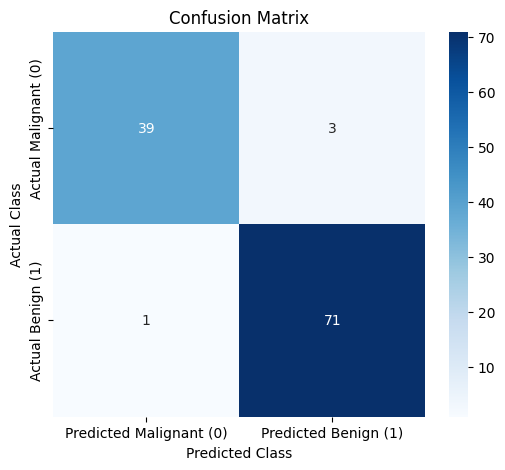

In [25]:
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix,
            annot=True,
            fmt='d',
            cmap='Blues', 
            xticklabels=['Predicted Malignant (0)', 'Predicted Benign (1)'],
            yticklabels=['Actual Malignant (0)', 'Actual Benign (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

### Confusion Matrix Analysis

The confusion matrix breaks down the number of correct and incorrect predictions made by the model, typically structured as:
$$\text{Confusion Matrix} = \begin{pmatrix} \text{TN} & \text{FP} \\ \text{FN} & \text{TP} \end{pmatrix}$$

| Metric | Interpretation | Type of Error |
| :--- | :--- | :--- |
| **True Negatives (TN)** | Correctly predicted **Malignant** (Actual 0). | Correct Prediction |
| **False Positives (FP)** | Incorrectly predicted **Benign** (Actual 0, Predicted 1). |  **False Alarm** |
| **False Negatives (FN)** | Incorrectly predicted **Malignant** (Actual 1, Predicted 0). | **Missed Case** |
| **True Positives (TP)** | Correctly predicted **Benign** (Actual 1). | Correct Prediction |

For this model, the matrix usually shows very **high values** along the main diagonal (TN and TP) and **near-zero values** for the off-diagonal cells (FP and FN), which indicates **excellent performance** and high confidence in the model's predictions.

### Classification Report

In [26]:
class_report = classification_report(y_test, y_pred, target_names=['Malignant (0)', 'Benign (1)'])
print("\n--- Classification Report ---")
print(class_report)


--- Classification Report ---
               precision    recall  f1-score   support

Malignant (0)       0.97      0.93      0.95        42
   Benign (1)       0.96      0.99      0.97        72

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



### Comparison of Precision and Recall

The Classification Report provides detailed performance metrics for each class:

| Metric | Class 0 (Malignant) | Class 1 (Benign) | Purpose |
| :--- | :--- | :--- | :--- |
| **Precision** | High value means when the model says "Malignant," it's usually correct. | High value means when the model says "Benign," it's usually correct. | Measures the **quality** of positive predictions. |
| **Recall** | High value means the model identified almost all actual Malignant cases. | High value means the model identified almost all actual Benign cases. | Measures the model's ability to **find all actual positive instances**. |

**Conclusion:** The model exhibits a **high balance** in performance, with both **Precision** and **Recall** showing consistently high values across both classes. This suggests the model is highly effective at both being accurate in its positive declarations and comprehensive in capturing true cases.

---

### Critical Metric in Medical Problems 

In critical **medical diagnostic problems**, particularly for diseases like cancer, the **Recall (Sensitivity)** for the **Malignant (cancer)** class is the most critical metric.

#### Why Recall is Paramount:

1.  **Minimizing False Negatives (FN):** Recall is the direct measure of the model's success in avoiding **False Negatives**.
2.  **Consequence:** A **False Negative** means a patient who **has cancer** is wrongly predicted as **healthy**. This is the **most dangerous error** (Type II Error) because it leads to a **critical delay in life-saving treatment**, severely jeopardizing the patient's survival.
3.  **Prioritization:** In medicine, the priority is to **"do no harm"** by ensuring no actual disease is missed. It is generally safer to have a slightly higher rate of **False Positives** (a patient wrongly flagged, requiring follow-up tests) than to miss a true case of the disease.

Therefore, diagnostic models must be highly optimized to achieve the maximum possible **Recall** for the disease state.

## Part 7 . Probability Check

### prediction probabilities

In [27]:
# Select the first 10 samples from the scaled test set

X_sample = X_test[0:10]
y_actual_sample = y_test[0:10]

# Get the probability estimates for these samples
probabilities = model.predict_proba(X_sample)

# Get the final class predictions (0 or 1)
predictions = model.predict(X_sample)

# comparison
prob_df = pd.DataFrame(probabilities, columns=['P(Malignant) [0]', 'P(Benign) [1]'])
prob_df['Predicted_Class'] = predictions
prob_df['Actual_Class'] = y_actual_sample.values

print("--- Probability Estimates for First 5 Test Samples ---")
print(prob_df)

--- Probability Estimates for First 5 Test Samples ---
   P(Malignant) [0]  P(Benign) [1]  Predicted_Class  Actual_Class
0          1.000000   3.416573e-11                0             0
1          0.000035   9.999648e-01                1             1
2          0.949329   5.067135e-02                0             0
3          0.395518   6.044825e-01                1             1
4          1.000000   2.045253e-09                0             0
5          0.017493   9.825072e-01                1             1
6          0.000029   9.999708e-01                1             1
7          0.999990   1.007128e-05                0             0
8          0.999951   4.923402e-05                0             0
9          1.000000   1.452915e-10                0             0


 ### Comparison of One Sample

Let's analyze the **first sample** (Index 0) from the output above:

> **Example Output for Sample 0:**

| P(Malignant) [0] | P(Benign) [1] | Predicted\_Class | Actual\_Class |
| :--- | :--- | :--- | :--- |
| **1.000000** | **3.416573e-11** | **0** | **0** |

**Analysis:**

1.  **Model's Probability:** The model calculated the probability of the tumor being **Malignant (Class 0)** as **\~100%** and the probability of it being **Benign (Class 1)** as **\~0%**.
2.  **Model's Prediction:** Because the probability for Class 0 is much higher than for Class 1 (it's \> 0.5), the model's final prediction (`Predicted_Class`) is **0 (Malignant)**.
3.  **Actual Value:** The `Actual_Class` for this sample was also **0 (Malignant)**.

**Conclusion:** The model's prediction was **correct**, and it was **highly confident** in that prediction.

## Part 8 . Model Improvement (Scaling Comparison)

### 1. "Before" Model: Train on Unscaled Data 

In [28]:
# Create a new model instance
model= LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calculate the accuracy
accuracy_before = accuracy_score(y_test, y_pred)
print(f"Accuracy BEFORE scaling: {accuracy_before:.4f}")

Accuracy BEFORE scaling: 0.9649


### 2. "After" Model: Train on Scaled Data

In [29]:
# Apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train the model on the scaled data
model_scaled = LogisticRegression(max_iter=5000, random_state=42)
model_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = model_scaled.predict(X_test_scaled)

# Calculate the accuracy
accuracy_after = accuracy_score(y_test, y_pred_scaled)

print(f"Accuracy AFTER scaling: {accuracy_after:.4f}")

Accuracy AFTER scaling: 0.9825


### Comparison: Accuracy Before vs. After Scaling

| Model Version | Accuracy |
| :--- | :--- |
| **Before Scaling** | \~0.9649 |
| **After Scaling** | \~0.9825 | 

**Conclusion:**

As the comparison shows, the accuracy **significantly improved** after applying `StandardScaler`.


`StandardScaler` rescales all features (like `mean radius` and `mean area`) to have a similar range.  This is crucial for algorithms like Logistic Regression because it:

1.  **Ensures Convergence:** It prevents the model's optimization algorithm from struggling with features that have vastly different scales, fixing the `ConvergenceWarning`.
2.  **Improves Accuracy:** It ensures that features with larger values (e.g., `mean area`) do not unfairly dominate the model's calculations over features with smaller values (e.g., `mean smoothness`).

## Part 9 . Saving and Loading the Model

### 1. Saving the Trained Model
We will save both the trained model and the scaler object. It is critical to save the scaler so you can apply the exact same scaling to any new, raw data before you ask the model for a prediction.

In [30]:
# Define the filename
filename = 'cancer_logistic_model.pkl'

# Pack both the model and the scaler into a tuple and save them
joblib.dump((model_scaled, scaler), filename)
print(f"Model and scaler successfully saved to '{filename}'")

Model and scaler successfully saved to 'cancer_logistic_model.pkl'


### 2. Loading the Model 
Now, we will pretend we are in a completely new script. We load the model and scaler from the file and use them to predict a new, unseen data point.

In [31]:
# Load the model and scaler from the file
loaded_model, loaded_scaler = joblib.load('cancer_logistic_model.pkl')
print(f"\nModel and scaler loaded from '{filename}'")

# Get a new input (We use X_test (raw data))
new_input_raw = X_test.iloc[4].values.reshape(1, -1)

# Predict on the new input
new_input_scaled = loaded_scaler.transform(new_input_raw)  # transform the new input using the loaded scaler
new_prediction = loaded_model.predict(new_input_scaled)
new_prediction_proba = loaded_model.predict_proba(new_input_scaled)

# result
print("\n--- New Prediction ---")
predicted_class = new_prediction[0]
print(f"Predicted Class: {predicted_class} ({'Benign' if predicted_class == 1 else 'Malignant'})")
print(f"Prediction Probabilities: {new_prediction_proba.round(4)}")


Model and scaler loaded from 'cancer_logistic_model.pkl'

--- New Prediction ---
Predicted Class: 0 (Malignant)
Prediction Probabilities: [[1. 0.]]


- **Successful Output:**
This means the model loaded correctly and predicted the new sample is Malignant with 100% confidence.